## ddHodge on surface

## Setup

In [1]:
using ddHodge
using GLMakie, GraphMakie, LinearAlgebra
using KrylovKit: eigsolve
using StatsBase: sample, mean, quantile, msd, rmsd

@isdefined(Dynamical2D) || include("../tools/Dynamical2D.jl")
using .Dynamical2D
using .Dynamical2D: spa, SurfaceFun.sphere

### Set graphic theme

In [30]:
forPrint = false # white background and SVG
if forPrint
    # for figure
    import CairoMakie
    CairoMakie.activate!(type="svg")
    set_theme!( 
        theme_minimal(),fontsize=14,fonts=(;regular="Helvetica"),
        Axis=(xticksvisible=true,yticksvisible=true,)
    )
    lc = :black
else
    # for daily use
    GLMakie.activate!(px_per_unit=1)
    set_theme!(
        theme_black(),
        backgroundcolor=RGBf([40,42,54]/255...),
        Colorbar = (spinewidth=0,),
        Legend = (backgroundcolor=:transparent,framevisible=false)
    )
    lc = :white
end
#Makie.theme(:fonts)
Makie.inline!(true)

true

## Surface

In [3]:
# Drawing shpere or torus
function uvsurface!(ax, shape;resol=200, scale=1.0, colorfun = (u,v) -> :steelblue, opts...)
    rlon = LinRange(-pi,pi,resol)
    rlat = if shape.type == :sphere 
        LinRange(-pi/2,pi/2-1e-6,resol)
    else
        LinRange(-pi,pi-1e-6,Int(resol/2))
    end
    # get i-th values
    slice(arr::Matrix,i::Int) = get.(arr,i,missing)
    # rescale radius for some purpose
    newshape = SetShape(shape.type;r=scale*shape.par.r)
    S = newshape.f.(rlon,rlat')
    plt = surface!(
        ax, [slice(S,i) for i in 1:3]...;
        color = colorfun.(rlon,rlat'),
        shading=NoShading, transparency=false
    )
    [plt[k] = v for (k,v) in opts] # set options
    plt
end

uvsurface! (generic function with 1 method)

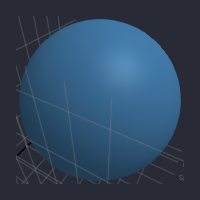

In [4]:
shape = SetShape(:sphere; r=1.0)
#shape = SetShape(:torus; r=0.5)
#shape = SetShape(:cylinder; r=1.0)

# Camera parameters
cpars = let
    eyedist = shape.type == :sphere ? shape.par.r + 1.7 : 4.0
    (
        eyeposition = Vec3f(eyedist*sphere(-pi/3,40pi/180,r=1.0)),
        lookat = shape.type == :sphere ? Vec3f(0) : Vec3f(0,0,-0.2),
        up = Vec3f(0,0,1)
    )
end

# Check settings
fig = Figure(size=(200,200))
ax = LScene(fig[1,1])
uvsurface!(ax,shape,shading=true)
cam3d!(ax.scene, center=false)
update_cam!(ax.scene, cpars...)
fig

In [5]:
Makie.inline!(false);display(fig);Makie.inline!(true)

true

## Dynamical system

In [6]:
# Predefined 1/|√g|
drgi = let r = shape.par.r
    if shape.type == :sphere
        (x,y) -> 1/(r^2*cos(y))
    else
        (x,y) -> 1/(r*(1.0+r*cos(y)))
    end
end

J, G, Dc, divM, curlM = diffOpsM(shape.f;drgi=drgi)
μc = [-pi/2,0.0] # center of the potential peak

if shape.type == :sphere
    # For sphere: log-vMF
    U(x,y;μ=μc,κ=1.0) = κ*sphere(μ...)'*sphere(x,y)
    # Option 2: distance to the equator
    #U(x,y;μ=μc,κ=1.0) = exp(-y^2)
else
    # log cosine-BVMC energy on torus
    lbvmc(x,y;mx=0,my=0,k1=1,k2=1,k3=0) = k1*cos(x-mx)+k2*cos(y-my)+k3*cos(x-mx-y+my)
    # Scalar field of energy landscape U
    U(x,y) = 0.5*lbvmc(x,y,mx=μc[1],my=μc[2])
end

fg(x,y) = -∇(U)(x,y) # gradient part
#fc(x,y) = Dynamical2D.Q*drgi(x,y)\fg(x,y) # inverse-scaled gradient
fc(x,y) = [cos(y)^2,0] # curl part for sphere: J*G⁻¹*fc = J[:,1]
#fc(x,y) = [1,0] # cyclic part for cylinder
fp(x,y) = fg(x,y) + fc(x,y) # vector field on parameter space

# Velocity on parameter space for simulation
vfp(x) = G(x...)\fp(x...) # inverse-scaled vector field
# Velocity on tangent plane for observation
vft(x) = J(x...)*vfp(x) # (J √g⁻¹)'(J √g⁻¹) = I

# Vector calculus on M
divRM = divM(fp)
curlRM = curlM(fp)

#23 (generic function with 1 method)

In [7]:
# let
#     p(x,y) = fg(x,y)'G(x,y)*fc(x,y)
#     fig = Figure(size=(500,500))
#     ax = LScene(fig[1,1],show_axis=false)
#     uvsurface!(ax, shape, colorfun=p, colormap=:coolwarm)
#     fig
#     extrema(spa(p).(pts2))
# end

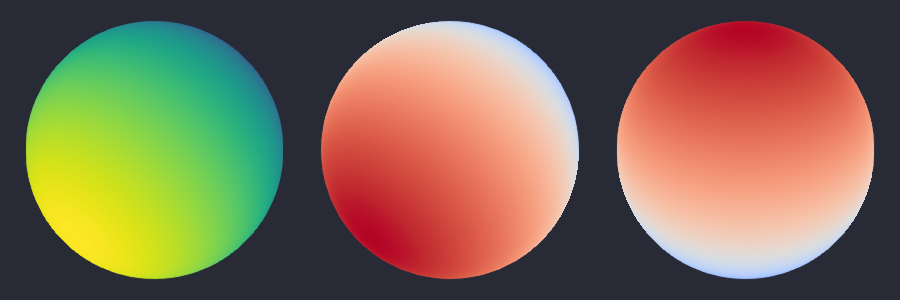

In [8]:
fig = let vmax=2
    fig = Figure(size=(900,300))
    axs = [LScene(fig[1,i],show_axis=false) for i in 1:3]
    uvsurface!(axs[1], shape, colorfun=U, colormap=:viridis)
    uvsurface!(axs[2], shape, colorfun=divRM, colormap=:coolwarm, colorrange=(-vmax,vmax))
    uvsurface!(axs[3], shape, colorfun=curlRM, colormap=:coolwarm, colorrange=(-vmax,vmax))
    for i in eachindex(axs)
        cam3d!(axs[i].scene, center=false)
        update_cam!(axs[i].scene, cpars...)
    end
    fig
end

## Uniform sampling on surface

In [9]:
# Uniform sampling on surface by the *easy* inverse sampling
function fakesample(n;type=:sphere)
    # Define probability P(x) using integration of riemannian metric
    if type == :sphere
        #pφ(x) = (x-sin(x)*cos(x))/pi
        pφ = x -> (1 + sin(x))/2
    else
        r=0.5
        R=1.0
        pφ = x -> ((x+pi)*(r^2+2R^2)+r*sin(x)*(r*cos(x)+4R))/2(pi*(r^2+2R^2))
    end
    # easy table imprementation of inverse function
    intrange = collect(LinRange((type == :sphere ? (-pi/2,pi/2) : (-pi,pi))...,1000))
    invtable = pφ.(intrange)
    [intrange[argmin(abs.(x.-invtable))] for x in rand(n)]
end

fakesample (generic function with 1 method)

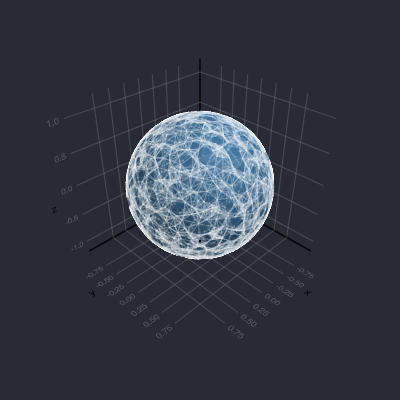

In [10]:
import Random
Random.seed!(123)
N = 2000
X2 = [pi*(2rand(N).-1) fakesample(N;shape.type)]'

# upper half
#X2 = X2[:,X2[2,:] .> 0]
#N = size(X2,2)

V2 = stack(vfp.(eachcol(X2)))
X = stack(spa(shape.f).(eachcol(X2)))

pts2 = Point2f.(eachcol(X2))
pts3 = Point3f.(spa(shape.f).(pts2))
V = stack(vft.(eachcol(X2)))
g, kdtree, = kNNGraph(X,10)
fig = Figure(size=(400,400))
ax = LScene(fig[1,1])
uvsurface!(ax, shape, transparency=true, shading=true)
graphplot!(ax,g,layout=pts3,node_size=0,edge_width=0.5,edge_attr=(transparency=true,))
fig

## Run ddHodge

In [11]:
ztop = argmax(X[3,:]) # the reference of face orientation
ddh = ddHodgeWorkflow(g,X,V,rdim=2,λ=0.1,ϵ=0.1,ssa=true,ssart=ztop)
#ddh = ddHodgeWorkflow(g,X,V,rdim=2,λ=0.0,ϵ=0.0,ssa=true,ssart=ztop)
ttu = stack([ddh.frames[i][:,1] for i in 1:N]) # parallel axis u
ttv = stack([ddh.frames[i][:,2] for i in 1:N]) # parallel axis v
# The sign of the rotation depends on the face orientation
fo = sign(det(ddh.planes[ztop][1:2,:])) # sign of z in (x,y,z) = u × v
@info "face orientation is $fo"
extrema(vec(sum(ttu.*ttv,dims=1))) # orthogonality of the axes

[ Info: (1/4) Potential estimation
[ Info: ... done in 2.85 sec.
[ Info: (2/4) Tangent space estimation
[ Info: Consistency of orientations: 1.0
[ Info: ... done in 2.233 sec.
[ Info: (3/4) Hessian matrix estimation
[ Info: ... done in 11.363 sec.
[ Info: (4/4) Jacobian matrix estimation
[ Info: Consistency of orientations (plane): 1.0
[ Info: ... done in 12.036 sec.
[ Info: face orientation is 1.0


(-1.6106699307627537e-11, 2.631629636429267e-11)

## Check results

norm((spa(divM(fp))).(pts2) - 2 * (spa(U)).(pts2)) = 2.7255445846239744e-6
norm((spa(curlM(fp))).(pts2) - 2 * sin.(last.(pts2))) = 1.1233621464112741e-6
[msd(xs, ys) for (xs, ys) = vpairs] = [0.0013458456249589217, 0.00043916747212800246, 0.0013519619561010263]


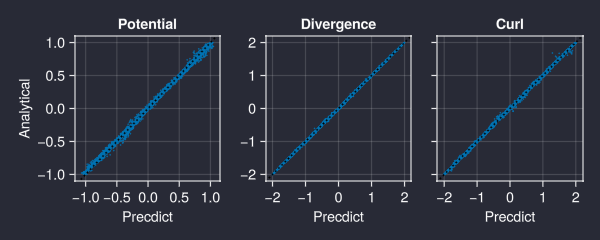

In [12]:
fig = let
    @show norm(spa(divM(fp)).(pts2) - 2spa(U).(pts2)) # 2U in sphere
    @show norm(spa(curlM(fp)).(pts2) - 2sin.(last.(pts2))) # 2sinφ in sphere
    uana, divana, rotana = [f.(pts2) for f in spa.([U,divM(fp),curlM(fp)])]
    uana = Float64.(uana)
    vmax = quantile([divana;rotana],0.99)
    ub = mean(ddh.u-uana) # bias can be ignored 
    vpairs = [(ddh.u.-ub, uana), (ddh.div, divana), (fo*ddh.rot, rotana)]
    @show [msd(xs,ys) for (xs,ys) in vpairs]
    fig = Figure(size=(600,240))
    titles = ["Potential","Divergence","Curl"]
    axs = [Axis(fig[1,i],aspect=1,xlabel="Precdict",title=titles[i]) for i in 1:3]
    [scatter!(axs[i], vpairs[i]..., markersize=2, rasterize=true) for i in eachindex(vpairs)]
    #xlims!(axs[2],(-vmax,vmax))
    #ylims!(axs[3],(-vmax,vmax))
    [axs[i].yticklabelsvisible=false for i in 3]
    axs[1].ylabel = "Analytical"
    #linkaxes!(axs[2:3]...)
    [ablines!(axs[i], [0], [1], color=:black, linestyle=:dot) for i in 1:3]
    fig
end

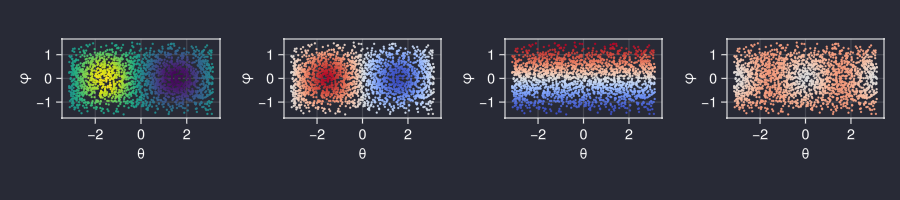

In [13]:
let ms = 3, vmax=2
    fig = Figure(size=(900,200))
    axs = [Axis(fig[1,i],aspect=2,xlabel="θ",ylabel="φ") for i in 1:4]
    scatter!(axs[1],pts2,color=ddh.u,markersize=ms,colormap=:viridis)
    for (i,vals) in enumerate([ddh.div, fo*ddh.rot, det.(ddh.J)])
        scatter!(axs[i+1],pts2,color=vals,markersize=ms,colormap=:coolwarm,colorrange=(-vmax,vmax),rasterize=true)
    end
    fig
end

 20.526302 seconds (7.49 M allocations: 5.270 GiB, 16.12% gc time, 43.66% compilation time)
vals = [0.027742833143006945, 0.0277428331430073, 0.028924555896319957, 0.028924555896324297, 0.029767868695870798, 0.02976786869587621, 0.1302928542010292, 0.130292854201033]


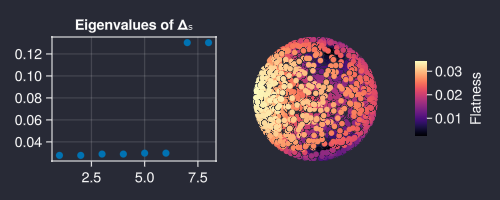

In [14]:
fig = let i=1, krytol=1e-32 # > 1e-16 may fail: 
    L = ddh.d0s'ddh.d0s
    @time vals, vecs, = eigsolve(L,8,:SR,issymmetric=true,tol=krytol)
    @show vals
    vlens = norm.(eachcol(reshape(vecs[i],2,:)))
    fig = Figure(size=(500,200))
    ax1 = Axis(fig[1,1],title="Eigenvalues of Δₛ")
    scatter!(ax1,vals,markersize=10)
    ax2 = LScene(fig[1,2],show_axis=false)
    #uvsurface!(ax2,shape,colorfun=(u,v) -> :white,transparency=true,scale=0.99)
    p = scatter!(ax2,pts3,color=vlens,colormap=:magma,markersize=8)
    #vps = ddh.frames .* eachcol(reshape(vecs[i],2,:)) .* vlens.^-1
    #p = quiver!(ax2,pts3,Vec3f.(0.1vps),linewidth=0.005,arrowsize=0,color=vlens,transparency=true,colormap=:cool)
    #quiver!(ax2,pts3,-Vec3f.(0.1vps),linewidth=0.005,arrowsize=0,color=vlens,transparency=true,colormap=:cool)
    cam3d!(ax2.scene, center=false)
    update_cam!(ax2.scene, cpars...)
    Colorbar(fig[1,3],p,height=Relative(0.6),label="Flatness")
    fig
end

  8.878750 seconds (393.78 k allocations: 3.851 GiB, 29.08% gc time)


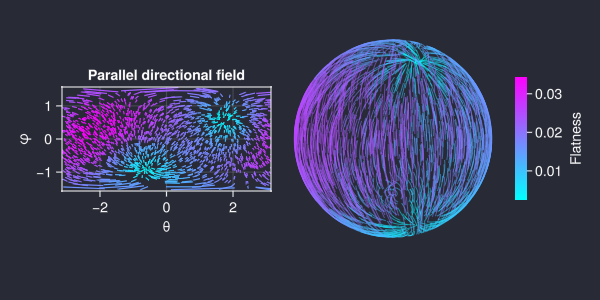

In [15]:
function makepal(cmap,x;resol=256)
    x = x .- minimum(x)
    idx = Int.(ceil.(x/maximum(x)*(resol-1))) # 0...255
    cgrad(cmap,resol)[idx.+1] # 1...256
end

fig = let i=1, j=i+1, b=[0,1], α=0.08, cmap=:cool, krytol=1e-18 # > 1e-16 may fail
    L = ddh.d0s'ddh.d0s
    @time vals, vecs, = eigsolve(L,8,:SR,issymmetric=true,tol=krytol)
    ulens = norm.(eachcol(reshape(vecs[i],2,:))) # norm(u) relates to the curvature
    # Prallel vector field on tangent planes
    ttu, ttv = [ddh.spans .* normalize.(eachcol(reshape(vecs[k],2,:))) for k in [i,j]]
    # Tangent -> param. space: vp = G^-1*J'*vt since Vt = J*vp
    T2P = [G(p...)\J(p...)' for p in pts2]
    ups, vps = [T2P .* ttx for ttx in [ttu,ttv]]
    zps = [Vec2f([u v]*b) for (u,v) in zip(ups,vps)]
    fig = Figure(size=(600,300))
    ax1 = Axis(fig[1,1],aspect=2,xlabel="θ",ylabel="φ",title="Parallel directional field")
    q = arrows2d!(ax1,pts2-α*zps,2α*zps,tipwidth=0,shaftwidth=1,color=ulens,colormap=cmap)
    xlims!(ax1,-pi,pi)
    yrange = shape.type == :sphere ? (-pi/2,pi/2) : (-pi,pi)
    ylims!(ax1,yrange...)
    Colorbar(fig[1,3],q,height=Relative(0.6),label="Flatness")
    ax2 = LScene(fig[1,2],show_axis=false)
    pal = makepal(cmap,ulens)
    for (i,p,v) in zip(eachindex(pts2), pts2, zps)
        traj = Point3f.(spa(shape.f).(LinRange(p-α*v,p+2α*v,40)))
        lines!(ax2,traj,color=pal[i],linewidth=0.5,transparency=true)
    end
    cam3d!(ax2.scene, center=false)
    update_cam!(ax2.scene, cpars...)
    fig
end

In [16]:
fig = let i=1, j=i+1, α=0.06, cmap=:cool, by=1, tmax=100
    psrc = Observable(fill(Point2f(0),N))
    pdst = Observable(fill(Point2f(0),N))
    wlens = Observable(fill(0.0,N))
    L = ddh.d0s'ddh.d0s
    @time vals, vecs, = eigsolve(L,8,:SR,issymmetric=true,tol=1e-18)
    #ulens = norm.(eachcol(reshape(vecs[i],2,:))) # norm(u) relates to the curvature
    # Prallel vector field on tangent planes
    us, vs = [eachcol(reshape(vecs[k],2,:)) for k in [i,j]]
    #ulens, vlens = [norm.(xs) for xs in [us,vs]]
    ttu, ttv = [ddh.spans .* normalize.(xs) for xs in [us,vs]]
    # Tangent -> param. space: vp = G^-1*J'*vt since Vt = J*vp
    T2P = [G(p...)\J(p...)' for p in pts2]
    ups, vps = [T2P .* ttx for ttx in [ttu,ttv]] # T2P*P*b
    fig = Figure(size=(500,300))
    ax1 = Axis(fig[1,1],aspect=2,xlabel="θ",ylabel="φ",title="Parallel directional field")
    q = arrows2d!(ax1,psrc,pdst,tipwidth=0,tiplength=0.4,shaftwidth=1,color=wlens,colormap=cmap)
    xlims!(ax1,-pi,pi)
    yrange = shape.type == :sphere ? (-pi/2,pi/2) : (-pi,pi)
    ylims!(ax1,yrange...)
    #Colorbar(fig[1,2],q,height=Relative(0.6),label="Flatness")
    vio = Record(fig, 1:by:tmax; framerate=30, profile ="high") do i
        θ = pi*i/tmax
        b = [cos(θ),sin(θ)]
        wlens[] = [norm([u v]*b) for (u,v) in zip(us,vs)]
        wps = [Vec2f([u v]*b) for (u,v) in zip(ups,vps)]
        psrc[] = pts2-α*wps
        pdst[] = 2α*wps
    end
end

 10.725544 seconds (393.44 k allocations: 3.847 GiB, 38.44% gc time)


VideoStream(Base.PipeEndpoint(RawFD(82) open, 0 bytes waiting), Process(setenv(`/home/kazumitsu.maehara/.julia/artifacts/0319290fc39dd3bdcb6fb33a4f25d7b8c511c762/bin/ffmpeg -y -loglevel quiet -threads 48 -framerate 30 -pixel_format rgb24 -f rawvideo -s:v 500x300 -r 30 -i pipe:0 -vf vflip -profile:v high -crf 20 -preset slow -c:v libx264 -pix_fmt yuv420p -an '/tmp/jl_fM0v2I/##video#232.mp4'`,["OPENBLAS_MAIN_FREE=1", "XKB_CONFIG_ROOT=/home/kazumitsu.maehara/.julia/artifacts/23d821271a00e164eb2b5c273985da44f9a831a1/share/X11/xkb", "PATH=/home/kazumitsu.maehara/.julia/artifacts/b8a470e4553346122607f94ec60d83c77f061cd6/bin:/home/kazumitsu.maehara/.julia/artifacts/020f522505f193c968b0a9d6199f7de2c4748cd2/bin:/home/kazumitsu.maehara/.julia/artifacts/cc3c4d36f2cf650d73959f9d7dec5cd0630bfb01/bin:/home/kazumitsu.maehara/.julia/artifacts/258f7271ca555a7634c0fe8b8508f69334673a89/bin:/home/kazumitsu.maehara/.julia/artifacts/c8a20a2030f10b70947d8d2a6bff7f8b5f343fe9/bin:/home/kazumitsu.maehara/.julia/artifacts/100f53309066fcdee2a61044b118ed3342683b67/bin:/home/kazumitsu.maehara/.julia/artifacts/bdb4015047b09c6ac5002f73dfd5be8ddf59189b/bin:/home/kazumitsu.maehara/.julia/artifacts/c9533bea1f28a1adea8cb096009f360534f7ba90/bin:/home/kazumitsu.maehara/.julia/artifacts/48d69f95e00f33788b0bddee11ce58dd15ba21e5/bin:/home/kazumitsu.maehara/.julia/artifacts/0319290fc39dd3bdcb6fb33a4f25d7b8c511c762/bin:/usr/local/packages/mambaforge/bin", "JULIA_PROJECT=@.", "JPY_SESSION_NAME=/home/kazumitsu.maehara/pynb/ddHodge_figures/notebook/surfsim_fig.ipynb", "DISPLAY=:1", "COLUMNS=80", "JUPYTERHUB_BASE_URL=/", "SHELL=/bin/bash", "JUPYTERHUB_OAUTH_ACCESS_SCOPES=[\"access:servers!server=kazumitsu.maehara/\", \"access:servers!user=kazumitsu.maehara\"]"  …  "LINES=30", "JUPYTERHUB_DEFAULT_URL=/lab", "LIBDECOR_PLUGIN_DIR=/home/kazumitsu.maehara/.julia/artifacts/38e215c51e5c0f77bc7a8813ba4586632a8fc750/lib/libdecor/plugins-1", "HOME=/home/kazumitsu.maehara", "JUPYTERHUB_USER=kazumitsu.maehara", "JUPYTERHUB_CLIENT_ID=jupyterhub-user-kazumitsu.maehara", "JUPYTERHUB_COOKIE_HOST_PREFIX_ENABLED=0", "JUPYTERHUB_OAUTH_SCOPES=[\"access:servers!server=kazumitsu.maehara/\", \"access:servers!user=kazumitsu.maehara\"]", "JUPYTERHUB_SERVICE_PREFIX=/user/kazumitsu.maehara/", "JUPYTERHUB_PUBLIC_URL="]), ProcessRunning), GLMakie.Screen(...), Makie.TickController(Observable(Makie.Tick(Makie.OneTimeRenderTick, 100, 3.3333333333333335, 0.03333333333333333)), 101, 0.03333333333333333, true, ObserverFunction defined at /home/kazumitsu.maehara/.julia/packages/Makie/4JW9B/src/ffmpeg-util.jl:199 operating on Observable(Tick(OneTimeRenderTick, 100, 3.33333, 0.0333333))), ColorTypes.RGB{FixedPointNumbers.N0f8}[RGB(0.0, 0.0, 0.0) RGB(0.796, 0.498, 0.0) … RGB(0.008, 0.0, 0.0) RGB(0.0, 0.0, 0.0); RGB(0.0, 0.0, 0.0) RGB(0.0, 0.941, 0.427) … RGB(0.0, 0.0, 0.0) RGB(0.0, 0.471, 0.059); … ; RGB(0.0, 0.0, 0.447) RGB(0.0, 0.0, 0.0) … RGB(1.0, 1.0, 0.0) RGB(0.475, 0.102, 0.0); RGB(0.427, 0.373, 0.286) RGB(0.0, 0.0, 0.0) … RGB(0.0, 0.0, 0.0) RGB(0.0, 0.0, 0.0)], "/tmp/jl_fM0v2I/##video#232.mp4", Makie.VideoStreamOptions("mp4", 30, 20, "high", "yuv420p", 0, "quiet", "pipe:0", true))

In [17]:
fig = let i=1, j=2, α=0.08, cmap=:coolwarm, clim=(-0.04,0.04), by=1, tmax=100
    psrc = Observable(fill(Point2f(0),N))
    pdst = Observable(fill(Point2f(0),N))
    wlens = Observable(fill(0.0,N))
    L = ddh.d0s'ddh.d0s
    @time vals, vecs, = eigsolve(L,8,:SR,issymmetric=true,tol=1e-18)
    #ulens = norm.(eachcol(reshape(vecs[i],2,:))) # norm(u) relates to the curvature
    # Prallel vector field on tangent planes
    us, vs = [eachcol(reshape(vecs[k],2,:)) for k in [i,j]]
    #ulens, vlens = [norm.(xs) for xs in [us,vs]]
    ttu, ttv = [ddh.spans .* normalize.(xs) for xs in [us,vs]]
    # Tangent -> param. space: vp = G^-1*J'*vt since Vt = J*vp
    T2P = [G(p...)\J(p...)' for p in pts2]
    ups, vps = [T2P .* ttx for ttx in [ttu,ttv]] # T2P*P*b
    fig = Figure(size=(700,300))
    ax1 = Axis(fig[1,1],aspect=2,xlabel="θ",ylabel="φ",title="<Killing v.f., Given v.f>")
    streamplot!(ax1,Point2f ∘ spa(fp),-3..3,-1.5..1.5,arrow_size=6,colormap=[:white],alpha=0.8)
    q = arrows2d!(ax1,psrc,pdst,tipwidth=0,shaftwidth=0.8,color=wlens,colormap=cmap,colorrange=clim)
    ax2 = LScene(fig[1,2],show_axis=false)
    p = scatter!(ax2,pts3,color=wlens,colormap=cmap,colorrange=clim,markersize=8)
    cam3d!(ax2.scene, center=false)
    update_cam!(ax2.scene, cpars...)
    xlims!(ax1,-pi,pi)
    yrange = shape.type == :sphere ? (-pi/2,pi/2) : (-pi,pi)
    ylims!(ax1,yrange...)
    Colorbar(fig[1,3],q,height=Relative(0.6),label="Inner product")
    Cs = stack([[u v]'*S'w for (S,u,v,w) in zip(ddh.spans,us,vs,eachcol(V))])
    vio = Record(fig, 1:by:tmax; framerate=20, profile ="high") do i
        θ = 2pi*i/tmax
        b = [cos(θ),sin(θ)]
        #wlens[] = [norm([u v]*b) for (u,v) in zip(us,vs)]
        # inner products on tangent plane
        wlens[] = Cs'*b
        wps = [Vec2f([u v]*b) for (u,v) in zip(ups,vps)]
        psrc[] = pts2-α*wps
        pdst[] = 2α*wps
    end
end

  9.879413 seconds (401.06 k allocations: 3.922 GiB, 33.23% gc time)


VideoStream(Base.PipeEndpoint(RawFD(82) open, 0 bytes waiting), Process(setenv(`/home/kazumitsu.maehara/.julia/artifacts/0319290fc39dd3bdcb6fb33a4f25d7b8c511c762/bin/ffmpeg -y -loglevel quiet -threads 48 -framerate 20 -pixel_format rgb24 -f rawvideo -s:v 700x300 -r 20 -i pipe:0 -vf vflip -profile:v high -crf 20 -preset slow -c:v libx264 -pix_fmt yuv420p -an '/tmp/jl_ewttmN/##video#233.mp4'`,["OPENBLAS_MAIN_FREE=1", "XKB_CONFIG_ROOT=/home/kazumitsu.maehara/.julia/artifacts/23d821271a00e164eb2b5c273985da44f9a831a1/share/X11/xkb", "PATH=/home/kazumitsu.maehara/.julia/artifacts/b8a470e4553346122607f94ec60d83c77f061cd6/bin:/home/kazumitsu.maehara/.julia/artifacts/020f522505f193c968b0a9d6199f7de2c4748cd2/bin:/home/kazumitsu.maehara/.julia/artifacts/cc3c4d36f2cf650d73959f9d7dec5cd0630bfb01/bin:/home/kazumitsu.maehara/.julia/artifacts/258f7271ca555a7634c0fe8b8508f69334673a89/bin:/home/kazumitsu.maehara/.julia/artifacts/c8a20a2030f10b70947d8d2a6bff7f8b5f343fe9/bin:/home/kazumitsu.maehara/.julia/artifacts/100f53309066fcdee2a61044b118ed3342683b67/bin:/home/kazumitsu.maehara/.julia/artifacts/bdb4015047b09c6ac5002f73dfd5be8ddf59189b/bin:/home/kazumitsu.maehara/.julia/artifacts/c9533bea1f28a1adea8cb096009f360534f7ba90/bin:/home/kazumitsu.maehara/.julia/artifacts/48d69f95e00f33788b0bddee11ce58dd15ba21e5/bin:/home/kazumitsu.maehara/.julia/artifacts/0319290fc39dd3bdcb6fb33a4f25d7b8c511c762/bin:/usr/local/packages/mambaforge/bin", "JULIA_PROJECT=@.", "JPY_SESSION_NAME=/home/kazumitsu.maehara/pynb/ddHodge_figures/notebook/surfsim_fig.ipynb", "DISPLAY=:1", "COLUMNS=80", "JUPYTERHUB_BASE_URL=/", "SHELL=/bin/bash", "JUPYTERHUB_OAUTH_ACCESS_SCOPES=[\"access:servers!server=kazumitsu.maehara/\", \"access:servers!user=kazumitsu.maehara\"]"  …  "LINES=30", "JUPYTERHUB_DEFAULT_URL=/lab", "LIBDECOR_PLUGIN_DIR=/home/kazumitsu.maehara/.julia/artifacts/38e215c51e5c0f77bc7a8813ba4586632a8fc750/lib/libdecor/plugins-1", "HOME=/home/kazumitsu.maehara", "JUPYTERHUB_USER=kazumitsu.maehara", "JUPYTERHUB_CLIENT_ID=jupyterhub-user-kazumitsu.maehara", "JUPYTERHUB_COOKIE_HOST_PREFIX_ENABLED=0", "JUPYTERHUB_OAUTH_SCOPES=[\"access:servers!server=kazumitsu.maehara/\", \"access:servers!user=kazumitsu.maehara\"]", "JUPYTERHUB_SERVICE_PREFIX=/user/kazumitsu.maehara/", "JUPYTERHUB_PUBLIC_URL="]), ProcessRunning), GLMakie.Screen(...), Makie.TickController(Observable(Makie.Tick(Makie.OneTimeRenderTick, 100, 5.0, 0.05)), 101, 0.05, true, ObserverFunction defined at /home/kazumitsu.maehara/.julia/packages/Makie/4JW9B/src/ffmpeg-util.jl:199 operating on Observable(Tick(OneTimeRenderTick, 100, 5.0, 0.05))), ColorTypes.RGB{FixedPointNumbers.N0f8}[RGB(0.69, 0.2, 0.075) RGB(1.0, 1.0, 1.0) … RGB(0.0, 0.0, 0.0) RGB(0.0, 0.0, 0.0); RGB(0.216, 0.8, 0.498) RGB(1.0, 0.0, 0.0) … RGB(0.0, 0.0, 0.0) RGB(0.0, 0.0, 0.878); … ; RGB(0.0, 0.0, 0.0) RGB(1.0, 1.0, 1.0) … RGB(1.0, 1.0, 0.0) RGB(0.0, 0.0, 0.0); RGB(0.878, 1.0, 1.0) RGB(1.0, 1.0, 1.0) … RGB(0.0, 0.0, 0.0) RGB(0.0, 0.0, 0.0)], "/tmp/jl_ewttmN/##video#233.mp4", Makie.VideoStreamOptions("mp4", 20, 20, "high", "yuv420p", 0, "quiet", "pipe:0", true))

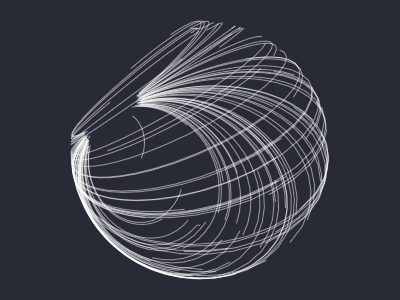

In [31]:
#with_theme(theme_minimal()) do
fig = let clim=(-2,2)
    fig = Figure(size=(400,300))
    ax = LScene(fig[1,1],show_axis=false)
    #uvsurface!(ax, shape, colorfun=U, colormap=[:white],transparency=true)
    cam3d!(ax.scene, center=false)
    update_cam!(ax.scene, cpars...)
    for i in 1:50, dir in [-1,1]
        traj = kutta(vfp, randn(2), dt=dir*0.1, s=50)
        ptraj = Point3f.(spa(shape.f).(eachcol(traj)))
        vs = [fp(p...)'*G(p...)*[1,0] for p in eachcol(traj)]
        #lines!(ptraj,color=vs,colormap=:coolwarm,linewidth=2,transparency=true,colorrange=clim)
        lines!(ptraj,color=lc,linewidth=0.5,transparency=true)
    end
    #Colorbar(fig[1,2],colormap=:coolwarm,colorrange=clim,height=Relative(0.6))
    fig
end
#end

## Run dynamo

In [19]:
import Muon
adata = Muon.AnnData(X=X',layers=Dict("velocity" => V'))
h5file = "../data/surfsim_$(string(shape.type)).h5ad"
Muon.writeh5ad(h5file,adata)

In [20]:
python = "/home/kazumitsu.maehara/work/ddhodge2025/envs/dynamo/bin/python"
run(`$python ../tools/dynamo_nopca.py $h5file`)
adata = Muon.readh5ad(h5file) # reload

/home/kazumitsu.maehara/work/ddhodge2025/envs/dynamo/lib/python3.11/site-packages/numba/np/ufunc/dufunc.py:344: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)
/home/kazumitsu.maehara/work/ddhodge2025/envs/dynamo/lib/python3.11/site-packages/numba/np/ufunc/dufunc.py:344: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)
/home/kazumitsu.maehara/work/ddhodge2025/envs/dynamo/lib/python3.11/site-packages/numba/np/ufunc/dufunc.py:344: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (

|-----> VectorField reconstruction begins...
|-----> Retrieve X and V based on basis: PCA. 
        Vector field will be learned in the PCA space.
|-----> Generating high dimensional grids and convert into a row matrix.
|-----> Learning vector field with method: sparsevfc.
|-----> [SparseVFC] begins...
|-----> Sampling control points based on data velocity magnitude...
|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected
|-----> [SparseVFC] completed [14.6139s]
|-----> [VectorField] completed [14.7680s]


Calculating 3-D curl:   0%|                           | 0/2000 [00:00<?, ?it/s]

|-----> [Calculating divergence with precomputed Jacobians] in progress: 22.6500%

Calculating 3-D curl: 100%|█████████████| 2000/2000 [00:00<00:00, 14351.42it/s]


|-----> [Calculating divergence with precomputed Jacobians] in progress: 100.0000%|-----> [Calculating divergence with precomputed Jacobians] completed [0.0361s]


Calculating divergence: 0it [00:00, ?it/s]


AnnData object with n_obs × n_vars = 2000 × 3
    obs: 'control_point_pca', 'inlier_prob_pca', 'obs_vf_angle_pca', 'jacobian_det_pca', 'curl_pca', 'divergence_pca'
    var: 'use_for_dynamics'
    uns: 'PCs', 'VecFld_pca', 'jacobian_pca'
    obsm: 'X_pca', 'velocity_pca', 'velocity_pca_SparseVFC', 'X_pca_SparseVFC', 'curl_pca'
    layers: 'velocity'


AnnData object 2000 ✕ 3

(msd(ddh.div, divana), msd(fo * ddh.rot, rotana)) = (0.00043916747212800246, 0.0013519619561010263)
(msd(adata.obs.divergence_pca, divana), msd(adata.obs.curl_pca, rotana)) = (0.03464875263095204, 5.41112162491618)


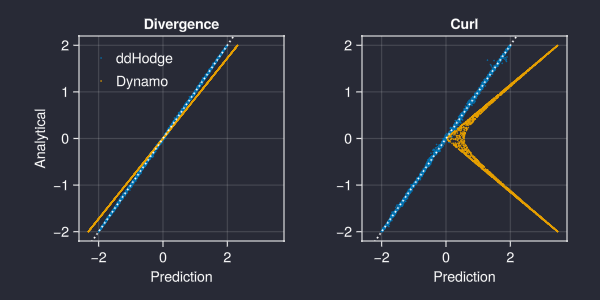

In [21]:
let 
    divana, rotana = [f.(pts2) for f in spa.([divM(fp),curlM(fp)])]
    @show msd(ddh.div,divana), msd(fo*ddh.rot,rotana)
    @show msd(adata.obs.divergence_pca,divana), msd(adata.obs.curl_pca,rotana)
    fig = Figure(size=(600,300))
    ax1 = Axis(fig[1,1],aspect=1,xlabel="Prediction",ylabel="Analytical",title="Divergence")
    ax2 = Axis(fig[1,2],aspect=1,xlabel="Prediction",title="Curl")
    scatter!(ax1,ddh.div,divana, markersize=2, label="ddHodge")
    scatter!(ax1,adata.obs.divergence_pca,divana, markersize=2, label="Dynamo")
    ablines!(ax1, [0], [1], color=:white, linestyle=:dot)
    scatter!(ax2, ddh.rot,rotana, markersize=2, label="ddHodge")
    scatter!(ax2, adata.obs.curl_pca,rotana, markersize=2, label="Dynamo")
    ablines!(ax2, [0], [1], color=:white, linestyle=:dot)
    axislegend(ax1, position = :lt)
    linkaxes!(ax1,ax2)
    fig
end


* ddHodge: rotation in the tangent plane
* Dynamo: rotation in the 3D space

In [22]:
eigvals(adata.uns["jacobian_pca"]["jacobian"][:,:,1])

3-element Vector{ComplexF64}:
   -0.3509458649933802 - 0.6917695181374371im
   -0.3509458649933802 + 0.6917695181374371im
 0.0004674275716693831 + 0.0im

In [23]:
eigvals(ddh.J[1])

2-element Vector{ComplexF64}:
 -0.3638938419004741 - 0.9301776496553272im
 -0.3638938419004741 + 0.9301776496553272im

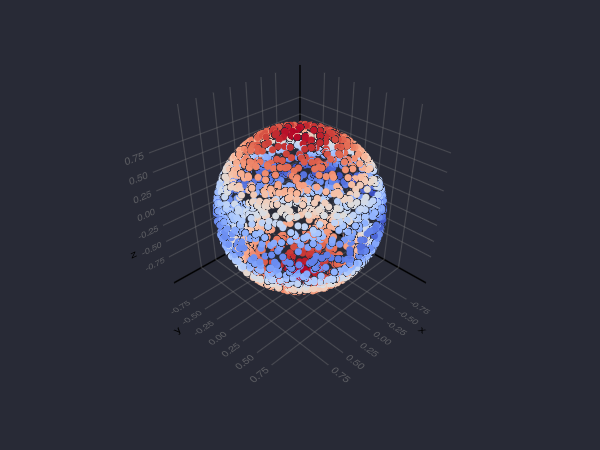

In [24]:
fig, = scatter(pts3,color=adata.obs.curl_pca,colormap=:coolwarm,markersize=10)
#scatter(pts3,color=ddh.rot,colormap=:coolwarm,markersize=10)